In [ ]:
!pip install pandas numpy matplotlib seaborn scikit-learn nltk empath nrclex --break-system-packages


Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 624.3/624.3 kB 11.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [nrclex]


In [9]:
import nltk; nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/nadia/nltk_data...


True

EXPLORATORY TEXT ANALYSIS — COMMENTS ON bat_score>0 POSTS
Loaded 54,935 comments; merged with bat_score for 54,935 (100.0%)

────────────────────────────────────────────────────────────
DESCRIPTIVE STATS
────────────────────────────────────────────────────────────
Posts with comments: 3,481
Comments per post — mean: 15.8, median: 7, max: 583

Word count — mean: 77.8, median: 51

Comments by subreddit:
subreddit_source
sysadmin                26652
cybersecurity           23813
SecurityCareerAdvice     2763
asknetsec                1531
ciso                      176
Name: count, dtype: int64

Comments by bat_score of parent post:
bat_score
1    29869
2    14086
3     8982
4     1998
Name: count, dtype: int64

────────────────────────────────────────────────────────────
SENTIMENT (VADER)
────────────────────────────────────────────────────────────
Overall VADER compound — mean: 0.255, median: 0.361

Mean VADER compound by parent-post bat_score:
bat_score
1    0.243
2    0.268
3    0.268


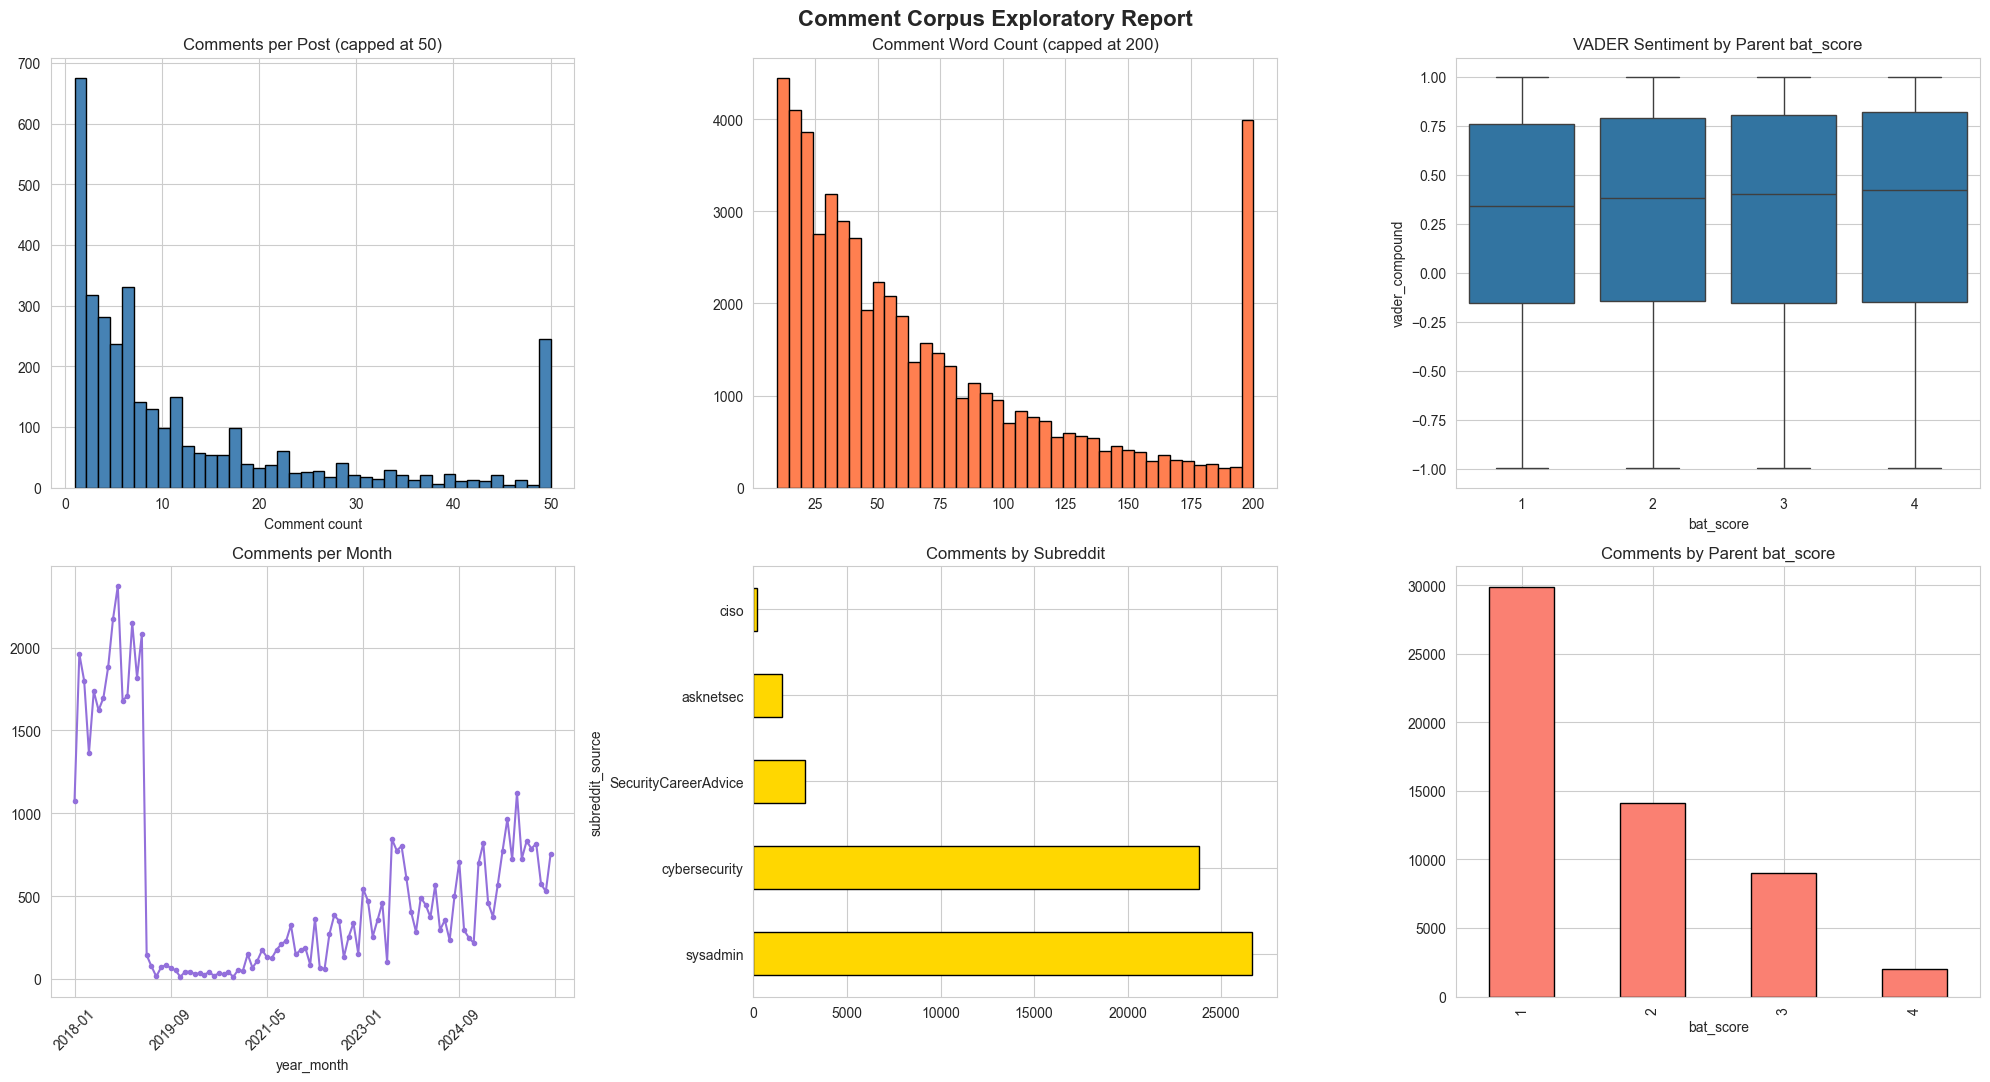

In [10]:
"""
EXPLORATORY TEXT ANALYSIS — TOP-LEVEL COMMENTS ON bat_score>0 POSTS
=====================================================================
Goal: cheap, open-source, lexicon-based first pass over the comment
corpus to surface patterns worth pursuing before committing to full
LLM support-type annotation. Covers:

  1. Descriptive stats (volume, length, temporal, by subreddit)
  2. Sentiment (VADER)
  3. Empath lexical categories (built-in, no license needed)
  4. NRC emotion lexicon (via nrclex — bundled locally, no download)
  5. Rough House (1983) support-type keyword heuristic
     (NOTE: this is a crude proxy for exploration only — your planned
     LLM annotation is the real measurement instrument, not this.)
  6. Top terms / bigrams by bat_score group

NOTE: an earlier draft included ad hoc "coping mechanism" keyword
categories (therapy, exercise, job-change, etc.). Those were NOT
grounded in any coping-literature framework (e.g. Carver's Brief COPE,
Lazarus & Folkman) and were removed rather than left in as unvalidated
output. If you want a coping analysis later, build it from a cited
taxonomy rather than ad hoc keywords.

Reads:
    master_comments_filtered.csv
    bat_score_pos.csv   (to join bat_score onto each comment's post)

Writes:
    comment_eda_summary.csv
    comment_eda_report.png   (multi-panel figure)

Install once:
    pip install nltk empath nrclex scikit-learn matplotlib seaborn --break-system-packages
    python3 -c "import nltk; nltk.download('vader_lexicon')"
"""

import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

from nltk.sentiment.vader import SentimentIntensityAnalyzer
from empath import Empath
from nrclex import NRCLex
from sklearn.feature_extraction.text import CountVectorizer

# ── CONFIGURATION ────────────────────────────────────────────────────────────
DATA_DIR = '/Users/nadia/Desktop/redditRun_june/comment_data/'
COMMENTS_FILE = DATA_DIR + 'master_comments_filtered.csv'
BAT_FILE = DATA_DIR + 'bat_score_pos.csv'
OUTPUT_DIR = DATA_DIR

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Empath categories worth watching for burnout/support context
# (full built-in list has ~200; this subset is the relevant slice)
EMPATH_CATEGORIES = [
    'help', 'support', 'affection', 'trust', 'sadness', 'fear', 'anger',
    'positive_emotion', 'negative_emotion', 'work', 'achievement',
    'money', 'health', 'exercise', 'medical_emergency', 'sympathy',
    'optimism', 'suffering', 'shame', 'fatigue', 'giving', 'stealing',
    'leaving', 'nervousness', 'friends', 'communication'
]

# Rough House (1983) support-type keyword heuristic — EXPLORATORY ONLY
SUPPORT_TYPE_KEYWORDS = {
    'emotional': [r'\bsorry\b', r'\bhugs?\b', r'\bhere for you\b', r'\bnot alone\b',
                  r'\bfeel(s|ing)? for you\b', r'\btough\b', r'\bstay strong\b'],
    'informational': [r'\btry\b', r'\brecommend', r'\bsuggest', r'\byou should\b',
                       r'\bconsider\b', r'\bresource\b', r'\blook into\b', r'\bcheck out\b'],
    'instrumental': [r'\bhere.?s a link\b', r'\bresume\b', r'\bjob posting\b', r'\bapply\b',
                      r'\breach out to\b', r'\bLinkedIn\b', r'\breferral\b', r'\bcontact me\b'],
    'appraisal': [r'\byou.?re doing (great|fine|well)\b', r'\bgood (job|call|move)\b',
                  r'\bmakes sense\b', r'\bthat.?s (valid|fair|reasonable)\b', r'\bproud of you\b'],
}


def compile_keyword_group(patterns):
    return re.compile('|'.join(patterns), flags=re.IGNORECASE)


def flag_keyword_groups(text, keyword_dict):
    """Returns dict of {group_name: 0/1} for whether any pattern in that group matched."""
    result = {}
    for group, patterns in keyword_dict.items():
        combined = compile_keyword_group(patterns)
        result[group] = 1 if combined.search(text) else 0
    return result


# ── STEP 1: LOAD + MERGE ────────────────────────────────────────────────────
def load_data():
    comments = pd.read_csv(COMMENTS_FILE)
    bat = pd.read_csv(BAT_FILE, usecols=['post_id', 'bat_score', 'EX', 'EMO', 'COG', 'MD'])

    comments['post_id'] = comments['post_id'].astype(str)
    bat['post_id'] = bat['post_id'].astype(str)

    merged = comments.merge(bat, on='post_id', how='left')
    print(f"Loaded {len(comments):,} comments; merged with bat_score for "
          f"{merged['bat_score'].notna().sum():,} ({merged['bat_score'].notna().mean()*100:.1f}%)")
    return merged


# ── STEP 2: DESCRIPTIVE STATS ───────────────────────────────────────────────
def descriptive_stats(df):
    print("\n" + "─" * 60)
    print("DESCRIPTIVE STATS")
    print("─" * 60)

    comments_per_post = df.groupby('post_id').size()
    print(f"Posts with comments: {comments_per_post.shape[0]:,}")
    print(f"Comments per post — mean: {comments_per_post.mean():.1f}, "
          f"median: {comments_per_post.median():.0f}, max: {comments_per_post.max():,}")

    print(f"\nWord count — mean: {df['word_count'].mean():.1f}, "
          f"median: {df['word_count'].median():.0f}")

    if 'subreddit_source' in df.columns:
        print("\nComments by subreddit:")
        print(df['subreddit_source'].value_counts())

    print("\nComments by bat_score of parent post:")
    print(df['bat_score'].value_counts(dropna=False).sort_index())

    return comments_per_post


# ── STEP 3: SENTIMENT (VADER) ───────────────────────────────────────────────
def sentiment_analysis(df):
    print("\n" + "─" * 60)
    print("SENTIMENT (VADER)")
    print("─" * 60)

    sia = SentimentIntensityAnalyzer()
    df['vader_compound'] = df['cleaned_body'].apply(
        lambda t: sia.polarity_scores(t)['compound'] if isinstance(t, str) and t.strip() else np.nan
    )

    print("Overall VADER compound — mean: {:.3f}, median: {:.3f}".format(
        df['vader_compound'].mean(), df['vader_compound'].median()))

    print("\nMean VADER compound by parent-post bat_score:")
    print(df.groupby('bat_score')['vader_compound'].mean().round(3))

    return df


# ── STEP 4: EMPATH CATEGORIES ───────────────────────────────────────────────
def empath_analysis(df, sample_n=None):
    print("\n" + "─" * 60)
    print("EMPATH LEXICAL CATEGORIES")
    print("─" * 60)

    lexicon = Empath()
    texts = df['cleaned_body'].fillna('')
    if sample_n and len(texts) > sample_n:
        print(f"  (Sampling {sample_n:,} of {len(texts):,} comments for speed)")
        sample_idx = texts.sample(sample_n, random_state=42).index
    else:
        sample_idx = texts.index

    scores = []
    for idx in sample_idx:
        result = lexicon.analyze(texts.loc[idx], categories=EMPATH_CATEGORIES, normalize=True)
        result['post_id'] = df.loc[idx, 'post_id']
        result['bat_score'] = df.loc[idx, 'bat_score']
        scores.append(result)

    empath_df = pd.DataFrame(scores)
    print("\nMean Empath category scores by bat_score:")
    print(empath_df.groupby('bat_score')[EMPATH_CATEGORIES].mean().round(4).T)

    return empath_df


# ── STEP 5: NRC EMOTION LEXICON ─────────────────────────────────────────────
def nrc_emotion_analysis(df, sample_n=None):
    print("\n" + "─" * 60)
    print("NRC EMOTION LEXICON")
    print("─" * 60)

    texts = df['cleaned_body'].fillna('')
    if sample_n and len(texts) > sample_n:
        sample_idx = texts.sample(sample_n, random_state=42).index
    else:
        sample_idx = texts.index

    rows = []
    for idx in sample_idx:
        try:
            emo = NRCLex(texts.loc[idx])
            freqs = emo.affect_frequencies
        except Exception:
            freqs = {}
        freqs['post_id'] = df.loc[idx, 'post_id']
        freqs['bat_score'] = df.loc[idx, 'bat_score']
        rows.append(freqs)

    nrc_df = pd.DataFrame(rows).fillna(0)
    emotion_cols = [c for c in nrc_df.columns if c not in ('post_id', 'bat_score')]
    print("\nMean NRC emotion frequencies by bat_score:")
    print(nrc_df.groupby('bat_score')[emotion_cols].mean().round(4).T)

    return nrc_df


# ── STEP 6: ROUGH SUPPORT-TYPE HEURISTIC ────────────────────────────────────
def support_type_heuristic(df):
    print("\n" + "─" * 60)
    print("SUPPORT-TYPE KEYWORD HEURISTIC (exploratory proxy only)")
    print("─" * 60)

    flags = df['body'].fillna('').apply(lambda t: flag_keyword_groups(t, SUPPORT_TYPE_KEYWORDS))
    flags_df = pd.DataFrame(list(flags))
    df = pd.concat([df.reset_index(drop=True), flags_df.reset_index(drop=True)], axis=1)

    print("\nComments matching each support-type keyword group:")
    for col in SUPPORT_TYPE_KEYWORDS.keys():
        n = df[col].sum()
        print(f"  {col:15s} {n:6,}  ({n/len(df)*100:.1f}%)")

    print("\nSupport-type match rate by parent-post bat_score:")
    print(df.groupby('bat_score')[list(SUPPORT_TYPE_KEYWORDS.keys())].mean().round(3).T)

    return df


# ── STEP 8: TOP TERMS BY BAT_SCORE GROUP ────────────────────────────────────
def top_terms_by_group(df, top_n=20):
    print("\n" + "─" * 60)
    print(f"TOP {top_n} BIGRAMS BY bat_score GROUP")
    print("─" * 60)

    for score in sorted(df['bat_score'].dropna().unique()):
        subset = df.loc[df['bat_score'] == score, 'cleaned_body'].dropna()
        if len(subset) < 20:
            continue
        vec = CountVectorizer(ngram_range=(2, 2), stop_words='english', max_features=top_n)
        X = vec.fit_transform(subset)
        counts = np.asarray(X.sum(axis=0)).flatten()
        terms = vec.get_feature_names_out()
        top = sorted(zip(terms, counts), key=lambda x: -x[1])
        print(f"\nbat_score={int(score)}:")
        for term, count in top[:10]:
            print(f"  {term:30s} {count}")


# ── STEP 9: VISUALIZATION ───────────────────────────────────────────────────
def make_report_figure(df, comments_per_post):
    fig, axes = plt.subplots(2, 3, figsize=(20, 11))
    fig.suptitle('Comment Corpus Exploratory Report', fontsize=16, fontweight='bold')

    # Comments per post
    comments_per_post.clip(upper=50).hist(bins=40, ax=axes[0, 0], color='steelblue', edgecolor='black')
    axes[0, 0].set_title('Comments per Post (capped at 50)')
    axes[0, 0].set_xlabel('Comment count')

    # Word count distribution
    df['word_count'].clip(upper=200).hist(bins=40, ax=axes[0, 1], color='coral', edgecolor='black')
    axes[0, 1].set_title('Comment Word Count (capped at 200)')

    # VADER sentiment by bat_score
    if 'vader_compound' in df.columns:
        sns.boxplot(data=df, x='bat_score', y='vader_compound', ax=axes[0, 2])
        axes[0, 2].set_title('VADER Sentiment by Parent bat_score')

    # Comments over time
    if 'year_month' in df.columns:
        over_time = df.groupby('year_month').size()
        over_time.plot(ax=axes[1, 0], color='mediumpurple', marker='o', markersize=3)
        axes[1, 0].set_title('Comments per Month')
        axes[1, 0].tick_params(axis='x', rotation=45)

    # Comments by subreddit
    if 'subreddit_source' in df.columns:
        df['subreddit_source'].value_counts().plot(kind='barh', ax=axes[1, 1], color='gold', edgecolor='black')
        axes[1, 1].set_title('Comments by Subreddit')

    # Comments by bat_score
    df['bat_score'].value_counts().sort_index().plot(kind='bar', ax=axes[1, 2], color='salmon', edgecolor='black')
    axes[1, 2].set_title('Comments by Parent bat_score')

    plt.tight_layout()
    out_path = OUTPUT_DIR + 'comment_eda_report.png'
    plt.savefig(out_path, dpi=200, bbox_inches='tight')
    print(f"\n✓ Report figure saved: {out_path}")


# ── MAIN ─────────────────────────────────────────────────────────────────────
if __name__ == '__main__':
    print("=" * 80)
    print("EXPLORATORY TEXT ANALYSIS — COMMENTS ON bat_score>0 POSTS")
    print("=" * 80)

    df = load_data()
    comments_per_post = descriptive_stats(df)
    df = sentiment_analysis(df)

    # Empath/NRC can be slow on very large corpora — sample if needed
    SAMPLE_N = 20000 if len(df) > 20000 else None
    empath_df = empath_analysis(df, sample_n=SAMPLE_N)
    nrc_df = nrc_emotion_analysis(df, sample_n=SAMPLE_N)

    df = support_type_heuristic(df)
    top_terms_by_group(df)
    make_report_figure(df, comments_per_post)

    # Save row-level summary with all flags/scores attached
    df.to_csv(OUTPUT_DIR + 'comment_eda_summary.csv', index=False)
    print(f"\n✓ comment_eda_summary.csv saved  →  {len(df):,} rows")
    print("\n" + "=" * 80)
    print("EDA COMPLETE")
    print("=" * 80)